# Validate the representations and hyperparameter analysis

The representations of manifolds must be validated to ensure that 
1. the manifold is indeed the one we want. This is done by visualizing RDMs
2. the manifold is an attractor. This is done by preturbing along the attractor manifold and in the entire space; the attractor manifold should be more stable than the entire space.
3. the manifold integrates velocities on the manifold

Then, we can survey the hyperparameters to see the space of appropriate reps

Then, we can compare these fitted cells to actual cells. 

In [3]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from torch.optim import lr_scheduler as LR
from torch.utils.data import Dataset, DataLoader
import plotly.express as px
from functools import partial
from SimulateDatasets.ContrastiveGenerator import ContrastiveGenerator, AR1_ordered_data_gen, OrderedDataset, SampledDataset
from Network_models.CANTrainer import CANTrainer
from Network_models.PartitionedRNN import PartitionedNet
from utils.path_settings import *
import seaborn as sns
import os
from Rotations import integrate_velocities, exp_quat, q_mult, integrate_quat_sequential
from Plots.AttractorPlots import *
from Plots.globe_plots import *
import utils
import pandas as pd
plt.rcParams['figure.titlesize'] = 18
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.handlelength'] = 1.5
plt.rcParams['legend.handleheight'] = 0.5
plt.rcParams['axes.spines.right'] = False
plt.rcParams[('axes.spines.top')] = False



2025-06-01 17:12:18.951274: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-01 17:12:18.961901: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-01 17:12:18.976567: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-01 17:12:18.976598: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-01 17:12:18.986553: I tensorflow/core/platform/cpu_feature_gua

/home/timmy/nonnormal/dummy/mental-rotations
loading


# load the models we want. 
 In this section, we are interested to do a full batch of proof of concept, for the manifolds I said to have trained. 
 manifold and dimension in the following: 
 [t, 1], [t, 2], [s, 2], [s, 3]

 nonlinearity just be tanh is fine
 everything else should be straightforward
 

In [6]:
# adjustable knobs 
knobs = {
        "batch_size" : 4096,
        "mini_batch_size" : 256,
        "repUnits" : 128,
        "model" : "PartitionedRNN", # or "PartitionedCTRNN"
        # "model": "FlexibleRNN",
        "manifold" : "t", #"custom", # or "S"
        # "manifold" : "custom",
        "dim" : 1,
        "zeroNullRep" : False,
        "zeroNullInput" : False,
        "biasRep" : True,
        "biasInput" : True,
        "hihr_identity": False, 
        "cParam" : True,
        "nonlinearity" : "tanh",
        # "nonlinearity": "BiologicalReLU",
        # "nonlinearity": "BiologicalTanh",
        # "nonlinearity": "relu",
        # "nonlinearity": "NormedReLU", 
        "inputEnveloping" : False,
        "loss" : "infonce",
        "triplet_weight" : 0, # only turn if loss is triplet
        "normalize" : False,
        "similarity_kernel" : None,
        "weight_decay_thresh" : -10,
        "L2norm_scalar": 0,
        "manifold_name": "ModifiedRingManifold",
        # "similarity_kernel": "cosine", 
        "similarity_kernel": "euclidean",
        "capacity": False, 
        "manifold_params": {
            "R":1, 
            "A":0.2, 
            "n":5,
        },
        "temperature": 0.7, 
        "invariance_weight": 1,  
        # "epsilon_max":0.1,
    }
for key, value in knobs.items():
    exec(f"{key} = {f"{value}" if type(value) != str else f'"{value}"'}")
if knobs['hihr_identity'] == False:
    knobs['hihr_identity'] = None
if knobs["L2norm_scalar"] == 0:
    knobs["L2norm_scalar"] = None
if knobs["similarity_kernel"] == "cosine":
    knobs["similarity_kernel"] = None

model_list = []
data_gen_list = []
for manifold_dim in [["t", 1], ["t", 2], ["s", 2], ["s", 3]]: 
    knobs["manifold"] = manifold_dim[0]
    knobs["dim"] = manifold_dim[1]
    if knobs["manifold"].lower() in ["s", "t"]: 
        manifold_specs = {
            "manifold_path": "SimulateDatasets.Manifolds", 
            "manifold_name": "Sphere" if knobs["manifold"].lower() == "s" else "Torus",
            "manifold_params": {"dim": knobs["dim"], 
                                }
        }

    if knobs["manifold"].lower() == "custom": 
        manifold_specs = {
            "manifold_path": "SimulateDatasets.Manifolds",
            "manifold_name": knobs["manifold_name"],
            "manifold_params": knobs["manifold_params"]
        }
    
    c_, d_ = utils.knobs2specs_CAN(knobs)
    trainer = CANTrainer(c_)
    path = utils.load_from_lookup(c_)
    trainer.load_model(path)
    model_list.append(trainer.model)
    data_gen = ContrastiveGenerator(d_ | {"device": "cpu"})
    data_gen_list.append(data_gen)
    

input_connected: True
1
no scheduler
input_connected: True
1
no scheduler
input_connected: True
1
no scheduler
input_connected: True
1
no scheduler


In [7]:
from ripser import ripser  # requires ripser[python] installed

def wrap(x: torch.Tensor) -> torch.Tensor:
    """
    Wrap an angle x (in radians) into [−π, +π).
    """
    return ((x + torch.pi) % (2 * torch.pi)) - torch.pi

def compute_betti_number(point_cloud: np.ndarray, homology_dim: int = 1) -> int:
    """
    Compute the Betti number β_homology_dim of a point cloud using persistent homology.
    We count the number of infinite bars in the H_dim persistence diagram.
    
    Args:
        point_cloud: (N, D) numpy array of points.
        homology_dim: which Betti number to compute (default β₁).
    Returns:
        betti: int, the Betti number in the specified dimension.
    """
    diagrams = ripser(point_cloud, maxdim=homology_dim)['dgms']
    # diagrams[h] is a (k, 2) array of (birth, death) for H_h
    # Infinite bars have death = ∞ (represented as np.inf)
    dgm = diagrams[homology_dim]
    # Count how many features have death == infinity
    betti = np.sum(np.isinf(dgm[:, 1]))
    return int(betti)

def plot_networks_on_manifolds(net_list, data_gens, name_list=None, dim_max=3, save_path=None, plot_one_additional=False):
    """
    Plots representations of neural networks on manifold datasets,
    removes all ticks, and annotates each plot with the manifold's Betti number β₁.

    Parameters:
        net_list (list): List of networks to evaluate.
        data_gens (list): Corresponding list of data generators for each network.
        name_list (list, optional): Names for each network/manifold. If None, defaults to "Network 0", etc.
        dim_max (int): Maximum number of color‐coding dimensions (rows) to plot.
        save_path (str, optional): If provided, save the final figure to this path.
        plot_one_additional (bool): If True, plot an extra quaternion‐projection column.

    Returns:
        None
    """
    num_networks = len(net_list)
    ncols = dim_max + 1 if plot_one_additional else dim_max

    fig, axes = plt.subplots(
        nrows=num_networks,
        ncols=ncols,
        figsize=(6 * num_networks, 5 * dim_max),
        subplot_kw={'projection': '3d'}
    )

    # Ensure axes is 2D for uniform indexing
    if num_networks == 1:
        axes = np.array([axes])
    if ncols == 1:
        axes = axes.reshape(num_networks, 1)

    if name_list is None:
        name_list = [f"Network {i}" for i in range(num_networks)]

    for col, (net, data_gen) in enumerate(zip(net_list, data_gens)):
        # 1) Generate data and compute Betti number on the manifold coordinates
        d = data_gen.generate_data(100, disregard_n_samples=True)
        pos = d.positions.cpu().numpy()   # shape (N, manifold_dim)

        # Compute β₁ (you can change homology_dim if you want β₀ or β₂, etc.)
        # betti1 = compute_betti_number(pos, homology_dim=1)

        # 2) Run the network on input data to get its latent representation
        data = d.data_base
        net.eval()
        net_cpu = net.to("cpu")
        with torch.no_grad():
            output = net_cpu(data.float().cpu(), truncate_output=True)

        final = output[:, -1] + net_cpu.rnn.c.reshape(1, -1)
        offset = final.mean(dim=0).detach()
        final = (final - offset).detach()

        # 3) PCA for visualization
        u, s, v = torch.svd(final)
        PCs_all = (final @ v[:, :]).cpu()             # shape (N, latent_dim)
        PCs = PCs_all[:, :3]                          # first 3 PCs

        manifold_dim = pos.shape[-1]
        colorings = [pos[:, i] for i in range(manifold_dim)]
        if manifold_dim == 4:
            # Special case for SO(3), color by rotation angle from quaternion scalar part
            colorings[0] = 2 * np.arccos(np.clip(d.positions[:, 0].cpu().numpy(), -1, 1))

        # 4) Plot each “color‐dimension” row
        for row in range(dim_max):
            ax = axes[col, row]

            # Remove all ticks on this 3D axis
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_zticks([])

            if row < len(colorings):
                c = colorings[row]
                sc = ax.scatter(
                    PCs[:, 0],
                    PCs[:, 1],
                    PCs[:, 2],
                    c=c,
                    cmap='twilight_shifted',
                    s=2,
                    alpha=0.7
                )
                cbar = fig.colorbar(sc, ax=ax, pad=0.1, shrink=0.7)
                cbar.set_label(f'Theta {row + 1}')
            else:
                ax.set_visible(False)

            # Set title only on the first row, including Betti number
            if row == 0:
                ax.set_title(f"{name_list[col]}")

            # Label y‐axis (row index) only for the first column
            if col == 0:
                ax.set_ylabel(f'Dim {row + 1}')

        # 5) Optional extra column: quaternion / Hopf projection
        if plot_one_additional:
            ax_extra = axes[col, dim_max]
            ax_extra.set_xticks([])
            ax_extra.set_yticks([])
            ax_extra.set_zticks([])

            qts = PCs_all[:, :4]
            projected_cx = hopf_fibration(qts).cpu().numpy()
            c = colorings[0] if manifold_dim > 0 else None

            sc = ax_extra.scatter(
                projected_cx[:, 0],
                projected_cx[:, 1],
                projected_cx[:, 2],
                c=c,
                cmap='turbo',
                s=2,
                alpha=0.7
            )
            cbar = fig.colorbar(sc, ax=ax_extra, pad=0.1, shrink=0.7)
            cbar.set_label('quat rotation')
            ax_extra.set_title(f"{name_list[col]})")

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()


def stereographic_projection(q: torch.Tensor) -> torch.Tensor:
    """
    Stereographic projection of unit quaternions q (shape (N,4)) into R^3.
    """
    q = q / q.norm(dim=-1, keepdim=True)
    return q[:, :-1] / (1 - q[:, -1].unsqueeze(-1))


def hopf_fibration(q: torch.Tensor) -> torch.Tensor:
    """
    Hopf fibration mapping of unit quaternions q (shape (N,4)) to S^2 (embedded in R^3).
    """
    x, y, z, w = q[:, 0], q[:, 1], q[:, 2], q[:, 3]
    X = 2 * (x * w + y * z)
    Y = 2 * (y * w - x * z)
    Z = w**2 - x**2 - y**2 + z**2
    return torch.stack([X, Y, Z], dim=-1)

In [8]:
def plot_networks_on_manifolds(net_list, data_gens, name_list = None, dim_max=3, save_path = None, plot_one_additional=False, lbpad = 10):
    """
    Plots representations of neural networks on manifold datasets.

    Parameters:
        net_list (list): List of networks to evaluate.
        data_gens (list): Corresponding list of data generators for each network.
        dim_max (int): Maximum number of rows (dimensions) to plot.

    Returns:
        None
    """
    num_networks = len(net_list)
    if plot_one_additional: 
        fig, axes = plt.subplots(nrows=num_networks, ncols=dim_max + 1, figsize=(6 * num_networks, 5 * dim_max),
                             subplot_kw={'projection': '3d'})
    else:
        # fig, axes = plt.subplots(nrows=num_networks, ncols=dim_max, figsize=(6 * num_networks, 5 * dim_max),
        #                      subplot_kw={'projection': '3d'})
        fig, axes = plt.subplots(nrows=num_networks, ncols=dim_max, figsize=(12, 8),
                             subplot_kw={'projection': '3d'})


    # Ensure axes are a 2D array for uniform indexing
    if dim_max == 1:
        axes = np.array([axes]).reshape(1, -1)
    
    if name_list is None: 
        name_list = [f"Network {i}" for i in range(len(net_list))]

    for col, (net, data_gen) in enumerate(zip(net_list, data_gens)):
        # Generate data and run through the network
        d = data_gen.generate_data(100, disregard_n_samples=True)
        data = d.data_base
        pos = d.positions
        net.eval()
        net = net.to("cpu")
        with torch.no_grad():
            output = net(data.float().cpu(), truncate_output=True)

        final = output[:, -1] + net.rnn.c.reshape(1, -1)
        offset = final.mean(dim=0).detach()
        final = (final - offset).detach()

        # Perform PCA for dimensionality reduction
        
        u, s, v = torch.svd(final)
        b = 0
        PCs_all = (final @ v[:, :]).cpu()
        PCs = PCs_all[:, b:b + 3]
        dim = pos.shape[-1]

        # Generate color coding based on data properties
        colorings = [pos[:, i].cpu().numpy() for i in range(dim)]
        if dim == 4: 
            # SO(3) is special
            colorings[0] = 2 * torch.acos(torch.clamp(d.positions[:, 0], -1, 1)).cpu().numpy()

        for row in range(dim_max):
            ax = axes[col, row]
            # Remove all ticks on this 3D axis

            ax.set_xlabel(f'PC 1', labelpad=lbpad, fontsize = 8)
            ax.set_ylabel(f'PC 2', labelpad=lbpad, fontsize = 8)
            ax.set_ylabel(f'PC 3', labelpad=lbpad, fontsize = 8)

            if row < len(colorings):
                # Normalize the coloring values to [0, 1]
                c = colorings[row]
                # c = (c - c.min()) / (c.max() - c.min())

                # Scatter plot
                # sc = ax.scatter(PCs[:, 0], PCs[:, 1], PCs[:, 2], c=c, cmap='turbo', s=2, alpha=0.7)
                sc = ax.scatter(PCs[:, 0], PCs[:, 1], PCs[:, 2], c=c, cmap='twilight_shifted', s=2, alpha=0.7)
                # Add a color bar
                cbar = fig.colorbar(sc, ax=ax, pad=0.1, shrink = 0.7)
                cbar.set_label(fr'$x_{row + 1}$')
                # ax.set_xticks([])
                # ax.set_yticks([])
                # ax.set_zticks([])
                ax.set_xticklabels([])
                ax.set_yticklabels([])
                ax.set_zticklabels([])
                
                ax.grid(True)
            elif row <= dim_max + 1:

                # Hide unused rows
                ax.set_visible(False)

            # Set labels and title for the first row only
            if row == 0:
                ax.set_title(name_list[col], pad = 0)

        if plot_one_additional: 
            ax = axes[col, dim_max]
            qts = PCs_all[:, 0:4]
            # qts/=qts.norm(dim = -1, keepdim = True)
            # qts = qts * ((qts[:, 0] > 0) * 2 - 1)[:, np.newaxis]
            # qts = qts.cpu().numpy()
            c = colorings[0]
            # projected_cx = quat2xs(qts)
            projected_cx = hopf_fibration(qts).cpu().numpy()
            sc = ax.scatter(projected_cx[:, 0], projected_cx[:, 1], projected_cx[:, 2], c=c, cmap='turbo', s=2, alpha=0.7)
            cbar = fig.colorbar(sc, ax=ax, pad=0.1, shrink = 0.7)
            cbar.set_label(f'quat rotation')
            ax.set_title(f"{name_list[col]} Quaternion Projection")

    # Adjust layout
    plt.suptitle('Network Representations on Manifolds')
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()

def stereographic_projection(q):
    # q: Tensor of shape (N, 4) (unit quaternions)
    q = q / q.norm(dim=-1, keepdim=True)  # Ensure unit quaternion
    return q[:, :-1] / (1 - q[:, -1].unsqueeze(-1))  # Stereographic projection to R^3

def hopf_fibration(q):
    # q: Tensor of shape (N, 4) (unit quaternions)
    x, y, z, w = q[:, 0], q[:, 1], q[:, 2], q[:, 3]
    X = 2 * (x * w + y * z)
    Y = 2 * (y * w - x * z)
    Z = w**2 - x**2 - y**2 + z**2
    return torch.stack([X, Y, Z], dim=-1)  # Shape (N, 3)


torch.Size([1000, 10, 1])
tensor(0.1040)
torch.Size([10000, 10, 2])
tensor(0.9667)
torch.Size([10000, 10, 2])
tensor(0.1977)
torch.Size([8000, 10, 3])
tensor(0.2739)


/tmp/ipykernel_871989/4193767009.py:111: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


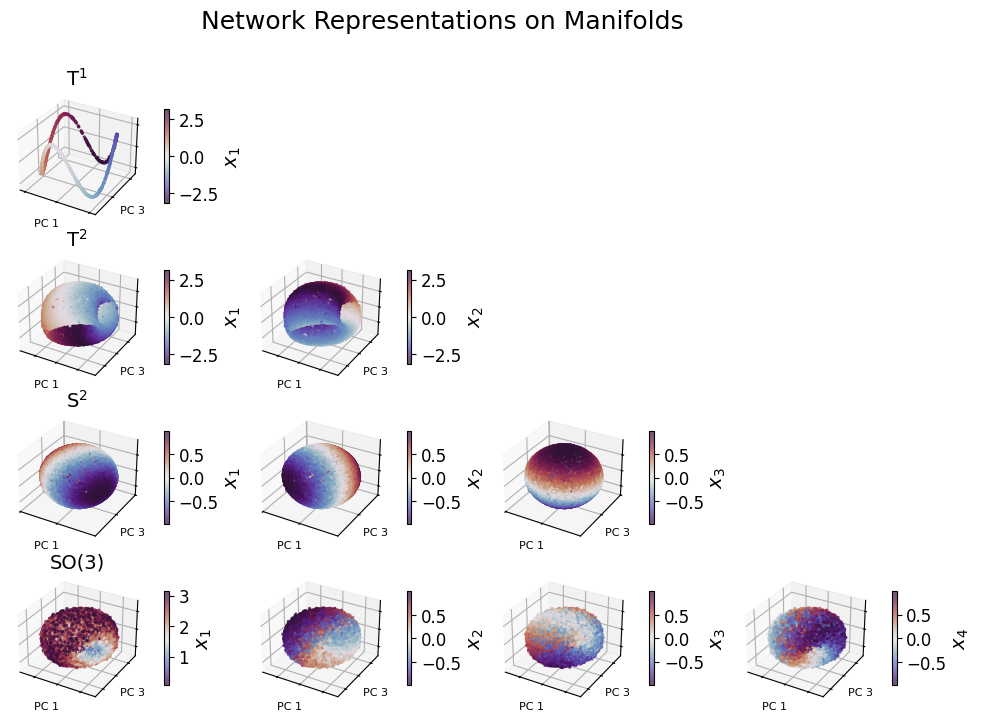

In [31]:
plot_networks_on_manifolds(model_list[:], data_gen_list[:], [r"T$^1$", r"T$^2$", r"S$^2$", r"SO(3)"], dim_max=4, save_path=FIG_PATH + "/PCA_visualisation_bReLU.png", plot_one_additional=False, lbpad = -10)


Second: test attractorness by adding noise


In [18]:
sigma_scalar = np.linspace(0, 1, 11)
num_samples = 1000
for i, scalar in enumerate(sigma_scalar): 
    noise = torch.randn(1000, )

In [29]:
def plot_noise_stuff(net_list, data_gens, name_list = None, save_path = None, dfs = None):

    num_networks = len(net_list)
    # fig, axes = plt.subplots(nrows=2, ncols=num_networks, figsize=(6 * num_networks, 10))
    fig, axes = plt.subplots(nrows = num_networks, ncols = 2, figsize = (6, 8))

    # Ensure axes are a 2D array for uniform indexing
   
    if name_list is None: 
        name_list = [f"Network {i}" for i in range(len(net_list))]

    if dfs is None:
        dfs = []
        no_dfs = True
    else: 
        no_dfs = False
    
    for row, (net, data_gen) in enumerate(zip(net_list, data_gens)):
        if no_dfs:
        # Generate data and run through the network
            d = data_gen.generate_data(100, disregard_n_samples=True)
            data = d.data_base
            net.eval()
            net = net.to("cpu")
            with torch.no_grad():
                output = net(data.float().cpu(), truncate_output=True)
                
            output = output[:, -1, :]
            sigma_scalar = torch.linspace(0.01, 1, 10)
            dw_norm = torch.zeros([10, output.shape[0]])
            dw_dir = torch.zeros([10, output.shape[0]])
            
            for i, scalar in enumerate(sigma_scalar): 
                noise = torch.randn_like(output) * scalar 
                noisy_output = noise + output
                dw = net.rnn.get_dW(noisy_output[:, -net.rnn.rep_units:])
                dw_norm_ = dw.norm(dim = 1)
                noise = noise[:, -net.rnn.rep_units:]
                noise /= noise.norm(dim = 1, keepdim = True)
                dw /= dw.norm(dim = 1, keepdim = True)
                
                dw_dir_ = torch.bmm(noise.unsqueeze(1), dw.unsqueeze(-1)).reshape(-1)
                dw_norm[i] = dw_norm_
                dw_dir[i] = dw_dir_

            # collate dw_dir, dw_norm, and the sigma level into a data frame and use sns to boxplot
            
            df = pd.DataFrame({"sigma": sigma_scalar.reshape(-1, 1).repeat(1, output.shape[0]).reshape(-1).cpu().detach().numpy(), 
                    "dw_norm": dw_norm.reshape(-1).cpu().detach().numpy(),
                    "dw_dir": dw_dir.reshape(-1).cpu().detach().numpy()})

        else: 
            df = dfs[row]
            sigma_scalar = df["sigma"].unique()
        sns.boxplot(x = "sigma", y = "dw_norm", data = df, ax = axes[row, 0],palette="rocket",showfliers=False)
        axes[row, 0].set_title(name_list[row])
        axes[row, 0].set_ylabel(r"$|| \nabla g ||$")
        axes[row, 0].set_xlabel("")
        
        sns.boxplot(x = "sigma", y = "dw_dir", data = df, ax = axes[row, 1], palette="rocket", showfliers =False)
        axes[row, 1].set_ylabel(r"$\frac{\langle \nabla g, d \rangle}{|| \nabla g || || d ||}$")

        # refactor the x ticks
        x_ticks = [f"{x:.1f}" for x in sigma_scalar]
        axes[row, 0].set_xticklabels(x_ticks, fontsize = 8)
        axes[row, 1].set_xticklabels(x_ticks, fontsize = 8)
        axes[row, 1].set_xlabel("")
        # Ensure the rows in each column share an x-axis
        dfs.append(df)

    axes[-1, 0].set_xlabel(r"$\sigma$")
    axes[-1, 1].set_xlabel(r"$\sigma$")
    # Adjust layout
    plt.suptitle('Network Noise Analysis')
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path)
    plt.show()
    return dfs

# dfs = plot_noise_stuff(model_list, data_gen_list, [r"T$^1$", r"T$^2$", r"S$^2$", r"S$^3$/SO(3)"], save_path=FIG_PATH + "/noise_visualisation.png")

/tmp/ipykernel_871989/1591277385.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = "sigma", y = "dw_norm", data = df, ax = axes[row, 0],palette="rocket",showfliers=False)
/tmp/ipykernel_871989/1591277385.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = "sigma", y = "dw_dir", data = df, ax = axes[row, 1], palette="rocket", showfliers =False)
/tmp/ipykernel_871989/1591277385.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row, 0].set_xticklabels(x_ticks, fontsize = 8)
/tmp/ipykernel_871989/1591277385.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks

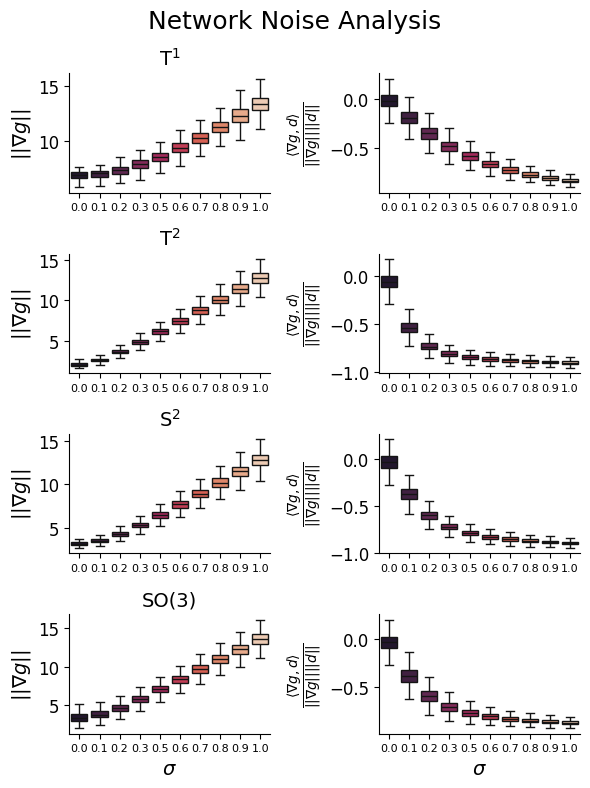

[      sigma    dw_norm    dw_dir
 0      0.01   5.399113 -0.011319
 1      0.01   5.222962  0.075824
 2      0.01   5.209733 -0.137239
 3      0.01   5.378785  0.003144
 4      0.01   5.328842  0.012911
 ...     ...        ...       ...
 9995   1.00  11.990080 -0.814744
 9996   1.00  14.922503 -0.873038
 9997   1.00  14.137969 -0.824396
 9998   1.00  13.305321 -0.852372
 9999   1.00  13.688242 -0.838569
 
 [10000 rows x 3 columns],
        sigma    dw_norm    dw_dir
 0       0.01   2.773478  0.033060
 1       0.01   2.511461  0.036430
 2       0.01   1.905015 -0.151551
 3       0.01   2.650249 -0.023031
 4       0.01   2.062356 -0.036531
 ...      ...        ...       ...
 99995   1.00  12.991627 -0.842688
 99996   1.00  12.101315 -0.892884
 99997   1.00  13.258980 -0.917954
 99998   1.00  13.083050 -0.908470
 99999   1.00  12.559398 -0.834637
 
 [100000 rows x 3 columns],
        sigma    dw_norm    dw_dir
 0       0.01   3.160537 -0.192593
 1       0.01   3.221272 -0.112013
 2      

In [30]:
plot_noise_stuff(model_list, data_gen_list, [r"T$^1$", r"T$^2$", r"S$^2$", r"SO(3)"], save_path=FIG_PATH + "/noise_visualisation.png", dfs=dfs)

# step 3: train decoder to prove uniqueness

In [15]:
sigma_scalar.reshape(-1, 1).repeat(1, 1000).reshape(-1)

tensor([0., 0., 0.,  ..., 1., 1., 1.])